# Project 4: End-to-End ML Pipeline Dashboard

Build a complete script that: loads raw sensor
CSV, cleans missing values, engineers two new
features (power = V*I, temp_ratio = temp/ambient), trains a fault classifier, prints a
full evaluation report, plots confusion matrix and
feature importances, and saves the model and
scaler to disk — all in one run.

### Skills: Feature engineering, full pipeline, model saving, report generation

--- EVALUATION REPORT ---
              precision    recall  f1-score   support

           0       0.67      0.77      0.71        13
           1       0.40      0.29      0.33         7

    accuracy                           0.60        20
   macro avg       0.53      0.53      0.52        20
weighted avg       0.57      0.60      0.58        20



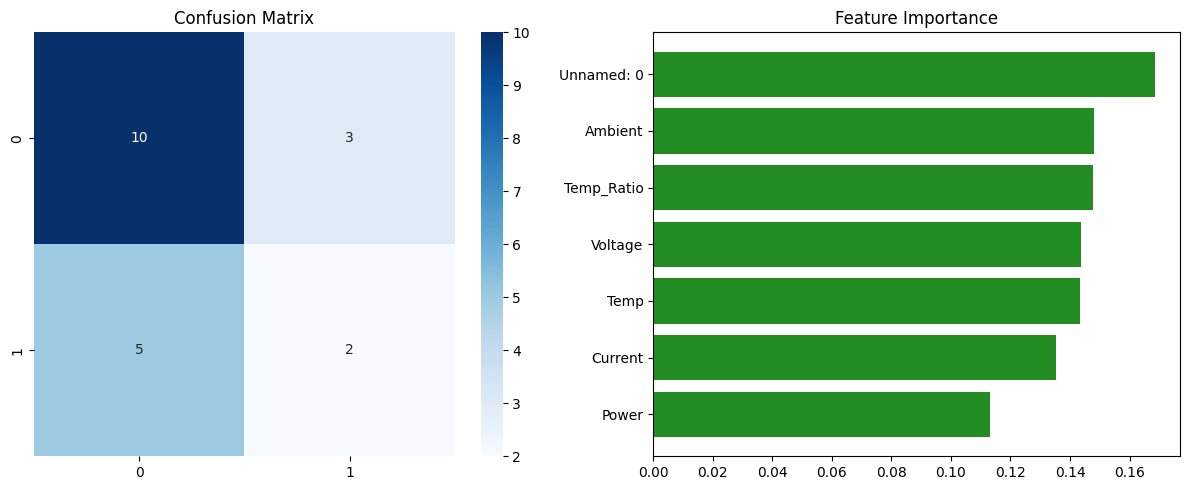

Model and Scaler successfully saved to disk.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# --- 1. DATA LOADING & CLEANING ---
def load_and_clean_data(file_path):
    # Simulating the loading of your sensor CSV
    df = pd.read_csv(file_path)
    
    # Handle missing values: Fill with median to stay robust against outliers
    df = df.fillna(df.median())
    
    return df

# --- 2. FEATURE ENGINEERING ---
def engineer_features(df):
    # Power = Voltage * Current
    df['Power'] = df['Voltage'] * df['Current']
    
    # Temp_Ratio = Internal_Temp / Ambient_Temp
    # Assuming your CSV has 'Temp' and 'Ambient' columns
    df['Temp_Ratio'] = df['Temp'] / df['Ambient']
    
    return df

# --- 3. THE PIPELINE EXECUTION ---
def run_full_pipeline(csv_path):
    # A. Preparation
    raw_data = load_and_clean_data(csv_path)
    data = engineer_features(raw_data)
    
    # Define features (X) and target (y)
    # Target is assumed to be 'Fault' (0 for normal, 1 for fault)
    X = data.drop(columns=['Fault'])
    y = data['Fault']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # B. Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # C. Training
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # D. Evaluation
    y_pred = model.predict(X_test_scaled)
    print("--- EVALUATION REPORT ---")
    print(classification_report(y_test, y_pred))
    
    # E. VISUALIZATION: Confusion Matrix
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    
    # F. VISUALIZATION: Feature Importance
    plt.subplot(1, 2, 2)
    importances = model.feature_importances_
    indices = np.argsort(importances)
    plt.barh(range(len(indices)), importances[indices], color='forestgreen')
    plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
    plt.title("Feature Importance")
    
    plt.tight_layout()
    plt.show()
    
    # G. MODEL SAVING (Persistence)
    joblib.dump(model, 'fault_classifier_model.pkl')
    joblib.dump(scaler, 'pipeline_scaler.pkl')
    print("Model and Scaler successfully saved to disk.")

run_full_pipeline('sensor_data.csv')